In [1]:
import torch
from evaluation_metrics import curve_posterior_slerp_deviation, curve_false_pos, curve_true_pos
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from torch.utils.data import DataLoader, TensorDataset, Subset
from utils import NestedDiagonalGMM
from geometry_tools import lerp
from pretrained_models import NestedVAE
from torch.nn.functional import cross_entropy, mse_loss
from typing import NamedTuple
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import numpy as np
from tqdm import tqdm
from posterior_manifold import FisherLogPosteriorManifold, PullbackRiemannianManifold
from dataclasses import dataclass
from collections.abc import Callable

def show_img(img, figsize=None, ax=None):
    if not ax:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot()
    img = img.detach()
    img = F.to_pil_image(img)
    ax.imshow(np.asarray(img), cmap='gray')
    ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

/usr/people/robertwiebe/testvenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
vae = NestedVAE()

/usr/people/robertwiebe/testvenv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/net/st1/export/clusterhome/robertwiebe/ml_geometry_project/pretrained_models.py:280: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torc

In [3]:
from matplotlib.ticker import MultipleLocator
def show_latent_curve(curve: torch.Tensor, title=None, ax=None, fontsize=None):
    if not ax:
        fig = plt.figure(figsize=(12, 1.25))
        ax = fig.add_subplot()
    with torch.no_grad():
        img = make_grid(vae.decode(curve), nrow=curve.shape[0])
    img = F.to_pil_image(img)
    ax.imshow(np.asarray(img), cmap='gray', extent=(0, 1, 0, 1/len(curve)))
    ax.yaxis.set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(True)
    ax.xaxis.set_major_locator(MultipleLocator(0.1))
    # ax.set_xlim(0, 1)
    if title:
        if fontsize:
            ax.set_title(title, fontsize=fontsize)
        else:
            ax.set_title(title)

attribute_names = ["5_o_Clock_Shadow", "Arched_Eyebrows", "Attractive", "Bags_Under_Eyes", "Bald", "Bangs", "Big_Lips", "Big_Nose", "Black_Hair", "Blond_Hair", "Blurry", "Brown_Hair", "Bushy_Eyebrows", "Chubby", "Double_Chin", "Eyeglasses", "Goatee", "Gray_Hair", "Heavy_Makeup", "High_Cheekbones", "Male", "Mouth_Slightly_Open", "Mustache", "Narrow_Eyes", "No_Beard", "Oval_Face", "Pale_Skin", "Pointy_Nose", "Receding_Hairline", "Rosy_Cheeks", "Sideburns", "Smiling", "Straight_Hair", "Wavy_Hair", "Wearing_Earrings", "Wearing_Hat", "Wearing_Lipstick", "Wearing_Necklace", "Wearing_Necktie", "Young"]

def show_posterior(curve: torch.Tensor, log_posterior, title=None, ax=None, top_n_labels: int | None = None):
    with torch.no_grad():
        posterior = torch.exp(log_posterior(curve.cuda()).cpu())
    if not ax:
        fig = plt.figure()
        ax = fig.add_subplot()
    if top_n_labels:
        prominence = posterior.sum(dim=0)
        order = prominence.sort(descending=True).indices
        top, others = order[:top_n_labels], order[top_n_labels:]
        ax.plot(
            posterior[:, top],
            label=[attribute_names[i] for i in top]
        )
        ax.plot(posterior[:, others], c='gray')
        ax.legend()
    else:
        ax.plot(posterior)
    if title: ax.set_title(title)

In [4]:
nested_gmm_params = torch.load('trained_checkpoints/celeba_nested_nested_gmm_4.pt')
nested_gmm = NestedDiagonalGMM(
    means=nested_gmm_params['means'],
    variances=nested_gmm_params['variances'],
    subweights=nested_gmm_params['subweights'],
    supweights=nested_gmm_params['supweights'],
)

/tmp/user/5678/ipykernel_3282032/2406645237.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  nested_gmm_params = torch.load('trained_checkpoints/celeba_nested_nested_gmm_

In [5]:
nested_gmm_params2 = torch.load('trained_checkpoints/celeba_nested_nested_gmm_4_independent.pt')
nested_gmm2 = NestedDiagonalGMM(
    means=nested_gmm_params2['means'],
    variances=nested_gmm_params2['variances'],
    subweights=nested_gmm_params2['subweights'],
    supweights=nested_gmm_params2['supweights'],
)

/tmp/user/5678/ipykernel_3282032/1888105894.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  nested_gmm_params2 = torch.load('trained_checkpoints/celeba_nested_nested_gmm

In [6]:
M = FisherLogPosteriorManifold(nested_gmm.log_posterior)

In [6]:
class MergedInterpolationGroup(NamedTuple):
    linline: torch.Tensor
    dec_geodesic: torch.Tensor
    ebm_geodesic: torch.Tensor
    geodesic: torch.Tensor
    slinline: torch.Tensor
    ebm_geodesic_2: torch.Tensor
    interp_latent: torch.Tensor
    interp_outer: torch.Tensor
    labels: torch.Tensor

In [7]:
interpolations: list[MergedInterpolationGroup] = torch.load('pickled_objects/interpolations_merged.pt')

/tmp/user/5678/ipykernel_3282032/1756387324.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  interpolations: list[MergedInterpolationGroup] = torch.load('pickled_objects/

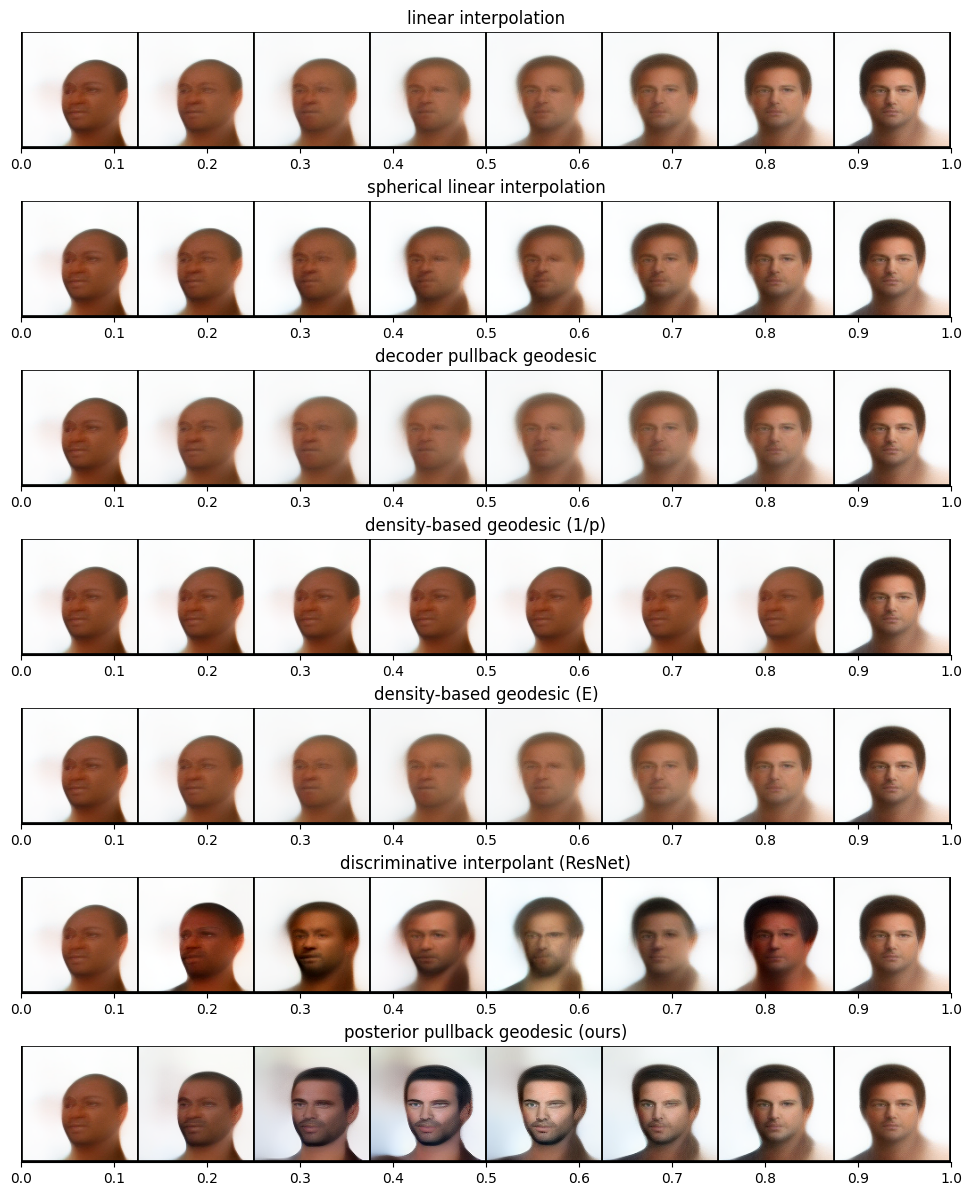

In [8]:
comp_idx = 15
interps = interpolations[comp_idx]
_, (ax1, ax2, ax3, ax4, ax5, ax6, ax7) = plt.subplots(7, 1, figsize=(12, 15))
show_latent_curve(interps.linline, 'linear interpolation', ax=ax1)
show_latent_curve(interps.slinline, 'spherical linear interpolation', ax=ax2)
show_latent_curve(interps.dec_geodesic, 'decoder pullback geodesic', ax=ax3)
show_latent_curve(interps.ebm_geodesic, 'density-based geodesic (1/p)', ax=ax4)
show_latent_curve(interps.ebm_geodesic_2, 'density-based geodesic (E)', ax=ax5)
show_latent_curve(interps.interp_outer, 'discriminative interpolant (ResNet)', ax=ax6)
show_latent_curve(interps.geodesic, 'posterior pullback geodesic (ours)', ax=ax7)
plt.show()

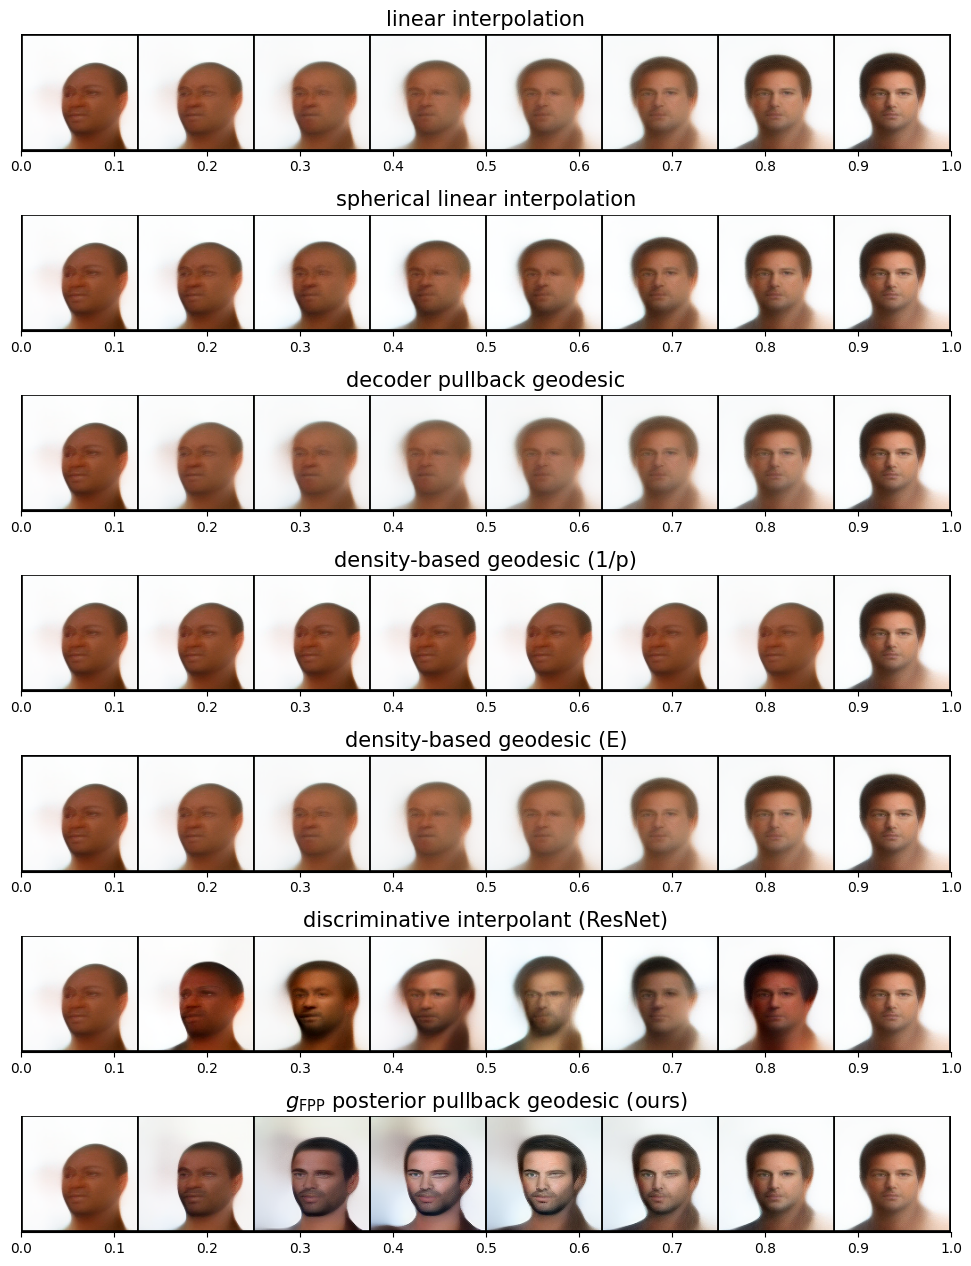

In [ ]:
comp_idx = 15
interps = interpolations[comp_idx]
_, (ax1, ax2, ax3, ax4, ax5, ax6, ax7) = plt.subplots(7, 1, figsize=(12, 16))
show_latent_curve(interps.linline, 'linear interpolation', ax=ax1, fontsize=15)
show_latent_curve(interps.slinline, 'spherical linear interpolation', ax=ax2, fontsize=15)
show_latent_curve(interps.dec_geodesic, 'decoder pullback geodesic', ax=ax3, fontsize=15)
show_latent_curve(interps.ebm_geodesic, 'density-based geodesic (1/p)', ax=ax4, fontsize=15)
show_latent_curve(interps.ebm_geodesic_2, 'density-based geodesic (E)', ax=ax5, fontsize=15)
show_latent_curve(interps.interp_outer, 'discriminative interpolant (ResNet)', ax=ax6, fontsize=15)
show_latent_curve(interps.geodesic, '$g_\\text{FPP}$ posterior pullback geodesic (ours)', ax=ax7, fontsize=15)
plt.savefig('results/comp_15.pdf', bbox_inches='tight')

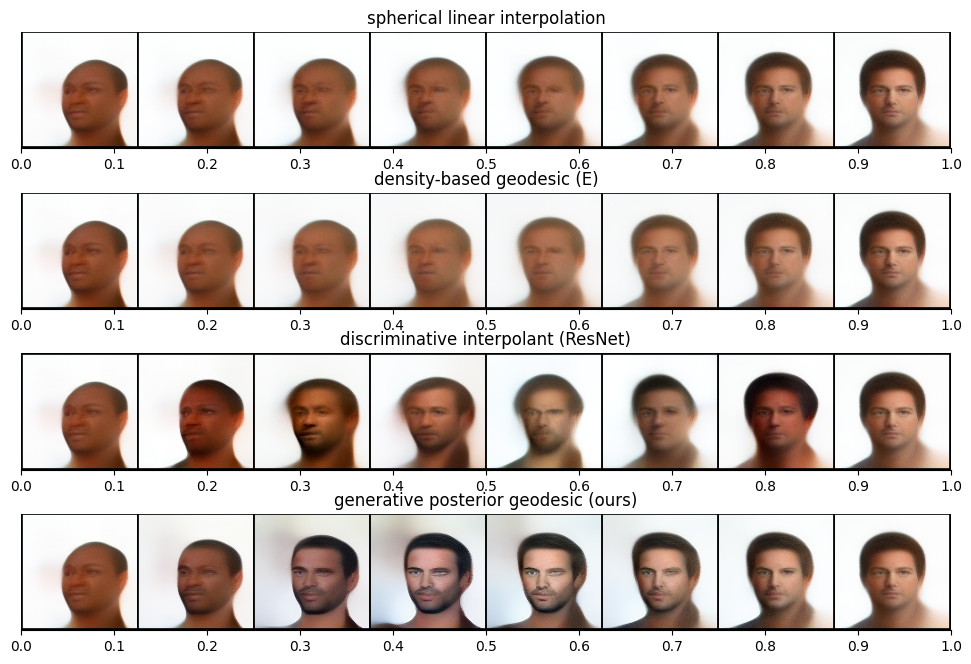

In [ ]:
comp_idx = 15
interps = interpolations[comp_idx]
_, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 8))
# show_latent_curve(interps.linline, 'linear interpolation', ax=ax1)
show_latent_curve(interps.slinline, 'spherical linear interpolation', ax=ax1)
# show_latent_curve(interps.dec_geodesic, 'decoder pullback geodesic', ax=ax3)
# show_latent_curve(interps.ebm_geodesic, 'density-based geodesic (1/p)', ax=ax4)
show_latent_curve(interps.ebm_geodesic_2, 'density-based geodesic (E)', ax=ax2)
show_latent_curve(interps.interp_outer, 'discriminative interpolant (ResNet)', ax=ax3)
show_latent_curve(interps.geodesic, 'generative posterior geodesic (ours)', ax=ax4)
plt.show()

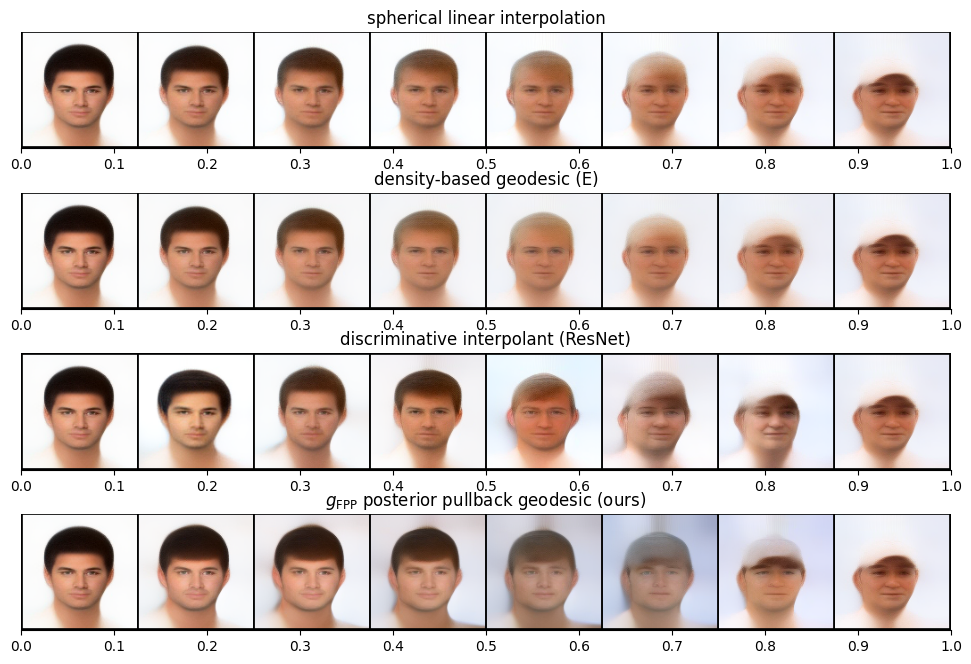

In [ ]:
comp_idx = 4
interps = interpolations[comp_idx]
_, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 8))
# show_latent_curve(interps.linline, 'linear interpolation', ax=ax1)
show_latent_curve(interps.slinline, 'spherical linear interpolation', ax=ax1)
# show_latent_curve(interps.dec_geodesic, 'decoder pullback geodesic', ax=ax3)
# show_latent_curve(interps.ebm_geodesic, 'density-based geodesic (1/p)', ax=ax4)
show_latent_curve(interps.ebm_geodesic_2, 'density-based geodesic (E)', ax=ax2)
show_latent_curve(interps.interp_outer, 'discriminative interpolant (ResNet)', ax=ax3)
show_latent_curve(interps.geodesic, '$g_\\text{FPP}$ posterior pullback geodesic (ours)', ax=ax4)
plt.savefig('results/comp_4.pdf', bbox_inches='tight')

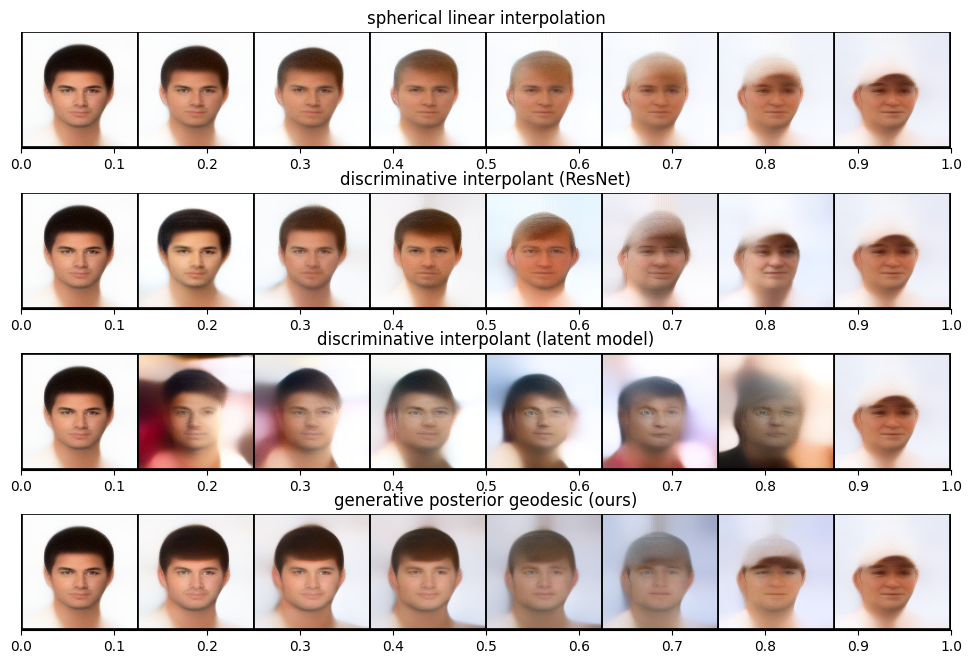

In [ ]:
comp_idx = 4
interps = interpolations[comp_idx]
_, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 8))
# show_latent_curve(interps.linline, 'linear interpolation', ax=ax1)
show_latent_curve(interps.slinline, 'spherical linear interpolation', ax=ax1)
# show_latent_curve(interps.dec_geodesic, 'decoder pullback geodesic', ax=ax3)
# show_latent_curve(interps.ebm_geodesic, 'density-based geodesic (1/p)', ax=ax4)
# show_latent_curve(interps.ebm_geodesic_2, 'density-based geodesic (E)', ax=ax2)
show_latent_curve(interps.interp_outer, 'discriminative interpolant (ResNet)', ax=ax2)
show_latent_curve(interps.geodesic, 'generative posterior geodesic (ours)', ax=ax4)
plt.show()

In [22]:
inception = InceptionScore(normalize=True)
for interp in tqdm(interpolations, 'Updating IS'):
    inception.update(vae.decode(interp.slinline))
inception.compute()

/usr/people/robertwiebe/testvenv/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
Updating IS: 100%|██████████| 100/100 [00:28<00:00,  3.52it/s]


(tensor(2.0652), tensor(0.1183))

In [7]:
inception = InceptionScore(normalize=True)
for interp in tqdm(interpolations, 'Updating IS'):
    inception.update(vae.decode(interp.ebm_geodesic_2))
inception.compute()

Updating IS:   0%|          | 0/100 [00:00<?, ?it/s]

Updating IS: 100%|██████████| 100/100 [00:30<00:00,  3.25it/s]


(tensor(2.0477), tensor(0.1526))

In [8]:
inception = InceptionScore(normalize=True)
for interp in tqdm(interpolations, 'Updating IS'):
    inception.update(vae.decode(interp.interp_outer))
inception.compute()

Updating IS: 100%|██████████| 100/100 [00:25<00:00,  3.92it/s]


(tensor(2.1354), tensor(0.1993))

In [9]:
lin_vals_list, slin_vals_list, dec_vals_list, ebm_vals_list, ebm2_vals_list, res_vals_list, geo_vals_list = [], [], [], [], [], [], []

for interps in tqdm(interpolations, 'Running evaluation'):
    lin_vals_list.append(curve_posterior_slerp_deviation(interps.linline.cuda(), nested_gmm.posterior).cpu())
    slin_vals_list.append(curve_posterior_slerp_deviation(interps.slinline.cuda(), nested_gmm.posterior).cpu())
    dec_vals_list.append(curve_posterior_slerp_deviation(interps.dec_geodesic.cuda(), nested_gmm.posterior).cpu())
    ebm_vals_list.append(curve_posterior_slerp_deviation(interps.ebm_geodesic.cuda(), nested_gmm.posterior).cpu())
    ebm2_vals_list.append(curve_posterior_slerp_deviation(interps.ebm_geodesic_2.cuda(), nested_gmm.posterior).cpu())
    res_vals_list.append(curve_posterior_slerp_deviation(interps.interp_outer.cuda(), nested_gmm.posterior).cpu())
    geo_vals_list.append(curve_posterior_slerp_deviation(interps.geodesic.cuda(), nested_gmm.posterior).cpu())

lin_vals = np.array(lin_vals_list)
slin_vals = np.array(slin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
ebm2_vals = np.array(ebm2_vals_list)
res_vals = np.array(res_vals_list)
geo_vals = np.array(geo_vals_list)

print("--- Final results for posterior slerp deviation---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Slerp:                {slin_vals.mean():.4f} ± {slin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM 1/p geodesic:     {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"EBM E geodesic:       {ebm2_vals.mean():.4f} ± {ebm2_vals.std():.4f}")
print(f"ResNet geodesic:     {res_vals.mean():.4f} ± {res_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

Running evaluation: 100%|██████████| 100/100 [00:00<00:00, 128.35it/s]

--- Final results for posterior slerp deviation---

Linear interpolation: 1.5240 ± 0.9346
Slerp:                0.8996 ± 0.7025
Decoder geodesic:     1.5874 ± 0.9815
EBM 1/p geodesic:     1.2927 ± 0.8148
EBM E geodesic:       2.2496 ± 1.3731
ResNet geodesic:     1.2634 ± 0.8760
Posterior geodesic:   0.0280 ± 0.0365


In [10]:
lin_vals_list, slin_vals_list, dec_vals_list, ebm_vals_list, ebm2_vals_list, res_vals_list, geo_vals_list = [], [], [], [], [], [], []

for interps in tqdm(interpolations, 'Running evaluation'):
    lin_vals_list.append(curve_true_pos(interps.linline.cuda(), nested_gmm.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    slin_vals_list.append(curve_true_pos(interps.slinline.cuda(), nested_gmm.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    dec_vals_list.append(curve_true_pos(interps.dec_geodesic.cuda(), nested_gmm.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    ebm_vals_list.append(curve_true_pos(interps.ebm_geodesic.cuda(), nested_gmm.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    ebm2_vals_list.append(curve_true_pos(interps.ebm_geodesic_2.cuda(), nested_gmm.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    res_vals_list.append(curve_true_pos(interps.interp_outer.cuda(), nested_gmm.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    geo_vals_list.append(curve_true_pos(interps.geodesic.cuda(), nested_gmm.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())

lin_vals = np.array(lin_vals_list)
slin_vals = np.array(slin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
ebm2_vals = np.array(ebm2_vals_list)
res_vals = np.array(res_vals_list)
geo_vals = np.array(geo_vals_list)

print("--- Final results for true positive score---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Slerp:                {slin_vals.mean():.4f} ± {slin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM 1/p geodesic:     {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"EBM E geodesic:       {ebm2_vals.mean():.4f} ± {ebm2_vals.std():.4f}")
print(f"ResNet geodesic:     {res_vals.mean():.4f} ± {res_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

Running evaluation: 100%|██████████| 100/100 [00:00<00:00, 164.44it/s]

--- Final results for true positive score---

Linear interpolation: 2.3285 ± 2.1783
Slerp:                2.7137 ± 2.3511
Decoder geodesic:     2.3540 ± 2.1610
EBM 1/p geodesic:     2.6149 ± 2.4979
EBM E geodesic:       2.0716 ± 2.0795
ResNet geodesic:     2.6869 ± 2.1308
Posterior geodesic:   2.7978 ± 2.4602


In [11]:
lin_vals_list, slin_vals_list, dec_vals_list, ebm_vals_list, ebm2_vals_list, res_vals_list, geo_vals_list = [], [], [], [], [], [], []

for interps in tqdm(interpolations, 'Running evaluation'):
    lin_vals_list.append(curve_false_pos(interps.linline.cuda(), nested_gmm.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    slin_vals_list.append(curve_false_pos(interps.slinline.cuda(), nested_gmm.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    dec_vals_list.append(curve_false_pos(interps.dec_geodesic.cuda(), nested_gmm.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    ebm_vals_list.append(curve_false_pos(interps.ebm_geodesic.cuda(), nested_gmm.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    ebm2_vals_list.append(curve_false_pos(interps.ebm_geodesic_2.cuda(), nested_gmm.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    res_vals_list.append(curve_false_pos(interps.interp_outer.cuda(), nested_gmm.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    geo_vals_list.append(curve_false_pos(interps.geodesic.cuda(), nested_gmm.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())

lin_vals = np.array(lin_vals_list)
slin_vals = np.array(slin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
ebm2_vals = np.array(ebm2_vals_list)
res_vals = np.array(res_vals_list)
geo_vals = np.array(geo_vals_list)

print("--- Final results for false positive score---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Slerp:                {slin_vals.mean():.4f} ± {slin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM 1/p geodesic:     {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"EBM E geodesic:       {ebm2_vals.mean():.4f} ± {ebm2_vals.std():.4f}")
print(f"ResNet geodesic:     {res_vals.mean():.4f} ± {res_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

Running evaluation: 100%|██████████| 100/100 [00:00<00:00, 204.23it/s]

--- Final results for false positive score---

Linear interpolation: 1.8470 ± 1.1736
Slerp:                1.7435 ± 1.0715
Decoder geodesic:     1.8201 ± 1.1500
EBM 1/p geodesic:     1.5407 ± 1.1010
EBM E geodesic:       2.0255 ± 1.3419
ResNet geodesic:     1.9672 ± 0.9802
Posterior geodesic:   1.3384 ± 0.8512


### Testing again

In [12]:
from geometry_tools import slerp
def curve_posterior_slerp_deviation2(curve: torch.Tensor, posterior, labels1, labels2) -> torch.Tensor:
    curve_posterior = posterior(curve)
    start, end = labels1 / labels1.sum(), labels2 / labels2.sum()
    slerp_target = slerp(start.sqrt(), end.sqrt(), torch.linspace(0, 1, curve.shape[0], device=curve.device)[:, None]).square()
    return mse_loss(curve_posterior, slerp_target, reduction='sum')

In [13]:
lin_vals_list, slin_vals_list, dec_vals_list, ebm_vals_list, ebm2_vals_list, res_vals_list, geo_vals_list = [], [], [], [], [], [], []

for interps in tqdm(interpolations, 'Running evaluation'):
    lin_vals_list.append(curve_posterior_slerp_deviation(interps.linline.cuda(), nested_gmm2.posterior).cpu())
    slin_vals_list.append(curve_posterior_slerp_deviation(interps.slinline.cuda(), nested_gmm2.posterior).cpu())
    dec_vals_list.append(curve_posterior_slerp_deviation(interps.dec_geodesic.cuda(), nested_gmm2.posterior).cpu())
    ebm_vals_list.append(curve_posterior_slerp_deviation(interps.ebm_geodesic.cuda(), nested_gmm2.posterior).cpu())
    ebm2_vals_list.append(curve_posterior_slerp_deviation(interps.ebm_geodesic_2.cuda(), nested_gmm2.posterior).cpu())
    res_vals_list.append(curve_posterior_slerp_deviation(interps.interp_outer.cuda(), nested_gmm2.posterior).cpu())
    geo_vals_list.append(curve_posterior_slerp_deviation(interps.geodesic.cuda(), nested_gmm2.posterior).cpu())

lin_vals = np.array(lin_vals_list)
slin_vals = np.array(slin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
ebm2_vals = np.array(ebm2_vals_list)
res_vals = np.array(res_vals_list)
geo_vals = np.array(geo_vals_list)

print("--- Final results for posterior slerp deviation---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Slerp:                {slin_vals.mean():.4f} ± {slin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM 1/p geodesic:     {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"EBM E geodesic:       {ebm2_vals.mean():.4f} ± {ebm2_vals.std():.4f}")
print(f"ResNet geodesic:     {res_vals.mean():.4f} ± {res_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

Running evaluation: 100%|██████████| 100/100 [00:00<00:00, 165.24it/s]

--- Final results for posterior slerp deviation---

Linear interpolation: 1.2948 ± 0.8176
Slerp:                0.8621 ± 0.6366
Decoder geodesic:     1.3488 ± 0.8207
EBM 1/p geodesic:     1.2005 ± 0.7963
EBM E geodesic:       2.0148 ± 1.1876
ResNet geodesic:     1.1943 ± 0.8445
Posterior geodesic:   0.2684 ± 0.3658


In [14]:
lin_vals_list, slin_vals_list, dec_vals_list, ebm_vals_list, ebm2_vals_list, res_vals_list, geo_vals_list = [], [], [], [], [], [], []

for interps in tqdm(interpolations, 'Running evaluation'):
    lin_vals_list.append(curve_posterior_slerp_deviation2(interps.linline.cuda(), nested_gmm2.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    slin_vals_list.append(curve_posterior_slerp_deviation2(interps.slinline.cuda(), nested_gmm2.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    dec_vals_list.append(curve_posterior_slerp_deviation2(interps.dec_geodesic.cuda(), nested_gmm2.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    ebm_vals_list.append(curve_posterior_slerp_deviation2(interps.ebm_geodesic.cuda(), nested_gmm2.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    ebm2_vals_list.append(curve_posterior_slerp_deviation2(interps.ebm_geodesic_2.cuda(), nested_gmm2.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    res_vals_list.append(curve_posterior_slerp_deviation2(interps.interp_outer.cuda(), nested_gmm2.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    geo_vals_list.append(curve_posterior_slerp_deviation2(interps.geodesic.cuda(), nested_gmm2.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())

lin_vals = np.array(lin_vals_list)
slin_vals = np.array(slin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
ebm2_vals = np.array(ebm2_vals_list)
res_vals = np.array(res_vals_list)
geo_vals = np.array(geo_vals_list)

print("--- Final results for posterior slerp deviation---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Slerp:                {slin_vals.mean():.4f} ± {slin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM 1/p geodesic:     {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"EBM E geodesic:       {ebm2_vals.mean():.4f} ± {ebm2_vals.std():.4f}")
print(f"ResNet geodesic:     {res_vals.mean():.4f} ± {res_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

Running evaluation: 100%|██████████| 100/100 [00:00<00:00, 149.31it/s]

--- Final results for posterior slerp deviation---

Linear interpolation: 3.0924 ± 1.3321
Slerp:                3.0874 ± 1.2739
Decoder geodesic:     3.0873 ± 1.3213
EBM 1/p geodesic:     3.3470 ± 1.5498
EBM E geodesic:       3.4837 ± 1.3842
ResNet geodesic:     2.8735 ± 1.0347
Posterior geodesic:   2.6481 ± 1.2367


In [15]:
lin_vals_list, slin_vals_list, dec_vals_list, ebm_vals_list, ebm2_vals_list, res_vals_list, geo_vals_list = [], [], [], [], [], [], []

for interps in tqdm(interpolations, 'Running evaluation'):
    lin_vals_list.append(curve_true_pos(interps.linline.cuda(), nested_gmm2.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    slin_vals_list.append(curve_true_pos(interps.slinline.cuda(), nested_gmm2.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    dec_vals_list.append(curve_true_pos(interps.dec_geodesic.cuda(), nested_gmm2.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    ebm_vals_list.append(curve_true_pos(interps.ebm_geodesic.cuda(), nested_gmm2.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    ebm2_vals_list.append(curve_true_pos(interps.ebm_geodesic_2.cuda(), nested_gmm2.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    res_vals_list.append(curve_true_pos(interps.interp_outer.cuda(), nested_gmm2.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    geo_vals_list.append(curve_true_pos(interps.geodesic.cuda(), nested_gmm2.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())

lin_vals = np.array(lin_vals_list)
slin_vals = np.array(slin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
ebm2_vals = np.array(ebm2_vals_list)
res_vals = np.array(res_vals_list)
geo_vals = np.array(geo_vals_list)

print("--- Final results for true positive score---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Slerp:                {slin_vals.mean():.4f} ± {slin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM 1/p geodesic:     {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"EBM E geodesic:       {ebm2_vals.mean():.4f} ± {ebm2_vals.std():.4f}")
print(f"ResNet geodesic:     {res_vals.mean():.4f} ± {res_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

Running evaluation: 100%|██████████| 100/100 [00:00<00:00, 233.94it/s]

--- Final results for true positive score---

Linear interpolation: 1.4620 ± 1.8330
Slerp:                1.4482 ± 1.8639
Decoder geodesic:     1.4788 ± 1.8004
EBM 1/p geodesic:     1.2745 ± 1.8501
EBM E geodesic:       1.3933 ± 1.8196
ResNet geodesic:     1.4181 ± 1.6068
Posterior geodesic:   1.4509 ± 1.8368


In [16]:
lin_vals_list, slin_vals_list, dec_vals_list, ebm_vals_list, ebm2_vals_list, res_vals_list, geo_vals_list = [], [], [], [], [], [], []

for interps in tqdm(interpolations, 'Running evaluation'):
    lin_vals_list.append(curve_false_pos(interps.linline.cuda(), nested_gmm2.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    slin_vals_list.append(curve_false_pos(interps.slinline.cuda(), nested_gmm2.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    dec_vals_list.append(curve_false_pos(interps.dec_geodesic.cuda(), nested_gmm2.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    ebm_vals_list.append(curve_false_pos(interps.ebm_geodesic.cuda(), nested_gmm2.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    ebm2_vals_list.append(curve_false_pos(interps.ebm_geodesic_2.cuda(), nested_gmm2.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    res_vals_list.append(curve_false_pos(interps.interp_outer.cuda(), nested_gmm2.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())
    geo_vals_list.append(curve_false_pos(interps.geodesic.cuda(), nested_gmm2.posterior, interps.labels[0].cuda(), interps.labels[1].cuda()).cpu())

lin_vals = np.array(lin_vals_list)
slin_vals = np.array(slin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
ebm2_vals = np.array(ebm2_vals_list)
res_vals = np.array(res_vals_list)
geo_vals = np.array(geo_vals_list)

print("--- Final results for false positive score---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Slerp:                {slin_vals.mean():.4f} ± {slin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM 1/p geodesic:     {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"EBM E geodesic:       {ebm2_vals.mean():.4f} ± {ebm2_vals.std():.4f}")
print(f"ResNet geodesic:     {res_vals.mean():.4f} ± {res_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

Running evaluation: 100%|██████████| 100/100 [00:00<00:00, 239.31it/s]

--- Final results for false positive score---

Linear interpolation: 2.6087 ± 1.6205
Slerp:                2.7684 ± 1.7505
Decoder geodesic:     2.5983 ± 1.6026
EBM 1/p geodesic:     2.7622 ± 1.8999
EBM E geodesic:       2.6420 ± 1.6204
ResNet geodesic:     3.0255 ± 1.5367
Posterior geodesic:   2.4458 ± 1.6012
